# COMP 3610 Assignment 3
## LLM-Powered Applications & Distributed Computing 
Denelle Mohammed
816039297


In [1]:
# Imports
import os
import json
import time
import requests
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import requests

from openai import OpenAI

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window

from pypdf import PdfReader

from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_community.vectorstores import Chroma
from langchain_community.embeddings import HuggingFaceEmbeddings

/Users/denellemohammed/COMP3610_A3/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Part 1: Distributed Data Processing with Spark

In [2]:
# Download taxi dataset programmatically
os.makedirs("data", exist_ok=True)

taxi_url = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet"
taxi_path = "data/yellow_tripdata_2024-01.parquet"

if not os.path.exists(taxi_path):
    print("Downloading taxi data...")
    r = requests.get(taxi_url, stream=True, timeout=60)
    r.raise_for_status()
    
    with open(taxi_path, "wb") as f:
        for chunk in r.iter_content(chunk_size=8192):
            if chunk:
                f.write(chunk)
    print("Download complete.")
else:
    print("Taxi data already exists.")

Taxi data already exists.


# Task 1.1: Spark Environment Setup & Data Loading

In [3]:
# Spark session
spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("COMP3610_Assignment3")
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.driver.memory", "4g")
    .config("spark.executor.memory", "4g")
    .getOrCreate()
)

print("Spark version:", spark.version)
print("App name:", spark.sparkContext.appName)
print("Master:", spark.sparkContext.master)
print("Default parallelism:", spark.sparkContext.defaultParallelism)

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/22 16:45:38 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version: 3.5.2
App name: COMP3610_Assignment3
Master: local[*]
Default parallelism: 8


In [4]:
# Compare Spark vs Pandas read performance
start = time.time()
df = spark.read.parquet(taxi_path)
spark_read_time = time.time() - start

start = time.time()
spark_rows = df.count()
spark_action_time = time.time() - start

start = time.time()
df_pd = pd.read_parquet(taxi_path)
pandas_time = time.time() - start

print(f"Spark schema read: {spark_read_time:.3f}s")
print(f"Spark count action: {spark_action_time:.3f}s ({spark_rows:,} rows)")
print(f"Pandas read: {pandas_time:.3f}s ({len(df_pd):,} rows)")
print(f"Partitions: {df.rdd.getNumPartitions()}")
df.printSchema()
df.show(5, truncate=True)

Spark schema read: 5.013s
Spark count action: 2.873s (2,964,624 rows)
Pandas read: 0.569s (2,964,624 rows)
Partitions: 8
root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- Airport_fee: double (nullable = true)



+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|Airport_fee|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+
|       2| 2024-01-01 00:57:55|  2024-01-01 01:17:43|              1|         1.72|         1|                 N|         186|          79|           2|       17.7|  1.0|    0.5|       0.

Pandas was faster than Spark for the initial Parquet read in this local experiment. Since the dataset fits on a single machine, this is expected. Pandas is optimized for in-memory processing on local workloads, whereas, Spark’s main advantage is scalability since it uses distributed processing, which become more beneficial for larger datasets and more complex analytical pipelines.

# Task 1.2: Data Cleaning & Feature Engineering in Spark

In [5]:
# Cleaning and feature engineering
initial_rows = df.count()
print(f"Initial rows: {initial_rows:,}")

critical_cols = [
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "PULocationID",
    "DOLocationID",
    "fare_amount",
    "trip_distance",
]

df_clean = df.dropna(subset=critical_cols)
rows_after_nulls = df_clean.count()
print(f"After null removal: {rows_after_nulls:,} | Removed: {initial_rows - rows_after_nulls:,}")

df_clean = df_clean.filter(F.col("trip_distance") > 0)
rows_after_distance = df_clean.count()
print(f"After distance filter: {rows_after_distance:,}")

df_clean = df_clean.filter(F.col("fare_amount") >= 0)
rows_after_fare = df_clean.count()
print(f"After fare filter: {rows_after_fare:,}")

df_clean = df_clean.filter(F.col("fare_amount") <= 500)
rows_after_cap = df_clean.count()
print(f"After high-fare cap: {rows_after_cap:,}")

df_clean = df_clean.filter(F.col("tpep_dropoff_datetime") >= F.col("tpep_pickup_datetime"))
rows_after_time = df_clean.count()
print(f"After time-order filter: {rows_after_time:,}")

df_clean = (
    df_clean
    .withColumn(
        "trip_duration_minutes",
        (
            F.unix_timestamp("tpep_dropoff_datetime") -
            F.unix_timestamp("tpep_pickup_datetime")
        ) / 60.0
    )
    .withColumn(
        "trip_speed_mph",
        F.when(
            F.col("trip_duration_minutes") > 0,
            F.col("trip_distance") / (F.col("trip_duration_minutes") / 60.0)
        )
    )
    .withColumn("pickup_hour", F.hour("tpep_pickup_datetime"))
    .withColumn("pickup_day_of_week", F.dayofweek("tpep_pickup_datetime"))
    .withColumn(
        "tip_percentage",
        F.when(
            F.col("fare_amount") > 0,
            (F.col("tip_amount") / F.col("fare_amount")) * 100
        )
    )
)

df_clean.select(
    "trip_distance", "fare_amount", "tip_amount",
    "trip_duration_minutes", "trip_speed_mph",
    "pickup_hour", "pickup_day_of_week", "tip_percentage"
).show(10, truncate=False)

final_rows = df_clean.count()
rows_removed = initial_rows - final_rows

print(f"Final cleaned rows: {final_rows:,}")
print(f"Total rows removed: {rows_removed:,}")
print(f"Percent removed: {rows_removed / initial_rows * 100:.2f}%")

Initial rows: 2,964,624
After null removal: 2,964,624 | Removed: 0


After distance filter: 2,904,253


After fare filter: 2,870,188


After high-fare cap: 2,870,158


After time-order filter: 2,870,102
+-------------+-----------+----------+---------------------+------------------+-----------+------------------+------------------+
|trip_distance|fare_amount|tip_amount|trip_duration_minutes|trip_speed_mph    |pickup_hour|pickup_day_of_week|tip_percentage    |
+-------------+-----------+----------+---------------------+------------------+-----------+------------------+------------------+
|1.72         |17.7       |0.0       |19.8                 |5.212121212121212 |0          |2                 |0.0               |
|1.8          |10.0       |3.75      |6.6                  |16.363636363636363|0          |2                 |37.5              |
|4.7          |23.3       |3.0       |17.916666666666668   |15.739534883720932|0          |2                 |12.875536480686694|
|1.4          |10.0       |2.0       |8.3                  |10.120481927710843|0          |2                 |20.0              |
|0.8          |7.9        |3.2       |6.1              

Final cleaned rows: 2,870,102
Total rows removed: 94,522
Percent removed: 3.19%


# Task 1.3: Spark SQL Analytics


In [6]:
df_clean.createOrReplaceTempView("taxi_trips")

*Query 1: What are the top 10 busiest pickup hours, and what is the average fare and tip percentage for each?*

In [7]:
q1 = spark.sql("""
SELECT
    pickup_hour,
    COUNT(*) AS trip_count,
    ROUND(AVG(fare_amount), 2) AS avg_fare,
    ROUND(AVG(tip_percentage), 2) AS avg_tip_pct
FROM taxi_trips
GROUP BY pickup_hour
ORDER BY trip_count DESC
LIMIT 10
""")
q1.show()


+-----------+----------+--------+-----------+
|pickup_hour|trip_count|avg_fare|avg_tip_pct|
+-----------+----------+--------+-----------+
|         18|    206284|   17.01|      22.78|
|         17|    200315|   18.12|      22.34|
|         16|    184971|   19.46|      21.84|
|         15|    184009|   19.11|       19.8|
|         19|    178812|   17.63|      22.86|
|         14|    178031|   19.27|       19.8|
|         13|    165361|   18.42|      19.79|
|         12|    159916|    17.8|      19.74|
|         21|    155915|   18.29|      21.88|
|         20|    155561|   18.05|      22.17|
+-----------+----------+--------+-----------+



The results show that taxi demand peaks during the late afternoon and early evening hours. This pattern is consistent with typical urban commuting behavior, where demand increases during the evening rush hour as people return home from work.


*Query 2: Which day of the week has the highest average trip speed? Include average distance and duration*

In [8]:
q2 = spark.sql("""
SELECT
    pickup_day_of_week,
    ROUND(AVG(trip_speed_mph), 2) AS avg_speed_mph,
    ROUND(AVG(trip_distance), 2) AS avg_distance,
    ROUND(AVG(trip_duration_minutes), 2) AS avg_duration_min
FROM taxi_trips
WHERE trip_speed_mph IS NOT NULL
GROUP BY pickup_day_of_week
ORDER BY avg_speed_mph DESC
""")
q2.show()

+------------------+-------------+------------+----------------+
|pickup_day_of_week|avg_speed_mph|avg_distance|avg_duration_min|
+------------------+-------------+------------+----------------+
|                 3|        17.46|        4.25|           16.18|
|                 1|        15.97|         3.9|           14.32|
|                 2|        13.85|        3.77|           15.85|
|                 6|        13.41|        3.68|           15.93|
|                 7|        13.26|        3.39|            14.9|
|                 5|        12.48|        3.54|           16.43|
|                 4|        12.38|        3.61|           16.26|
+------------------+-------------+------------+----------------+



Average trip duration remains relatively consistent across most days, ranging between approximately 14 to 16 minutes. However, the lower speeds observed on certain days suggest that similar trip durations are achieved over shorter distances, reinforcing the impact of congestion.


*Query 3: Using a window function, rank the top 5 pickup locations by total revenue for each day of the week.*

In [9]:
q3 = spark.sql("""
WITH revenue_by_location AS (
    SELECT
        pickup_day_of_week,
        PULocationID,
        SUM(total_amount) AS total_revenue
    FROM taxi_trips
    GROUP BY pickup_day_of_week, PULocationID
),
ranked AS (
    SELECT
        pickup_day_of_week,
        PULocationID,
        ROUND(total_revenue, 2) AS total_revenue,
        ROW_NUMBER() OVER (
            PARTITION BY pickup_day_of_week
            ORDER BY total_revenue DESC
        ) AS revenue_rank
    FROM revenue_by_location
)
SELECT *
FROM ranked
WHERE revenue_rank <= 5
ORDER BY pickup_day_of_week, revenue_rank
""")
q3.show(50, truncate=False)

+------------------+------------+-------------+------------+
|pickup_day_of_week|PULocationID|total_revenue|revenue_rank|
+------------------+------------+-------------+------------+
|1                 |132         |1564287.93   |1           |
|1                 |138         |763398.54    |2           |
|1                 |230         |346553.95    |3           |
|1                 |186         |264131.38    |4           |
|1                 |79          |263467.74    |5           |
|2                 |132         |2054606.73   |1           |
|2                 |138         |1021138.28   |2           |
|2                 |161         |460145.28    |3           |
|2                 |236         |373008.89    |4           |
|2                 |237         |372575.48    |5           |
|3                 |132         |1795093.56   |1           |
|3                 |138         |938393.12    |2           |
|3                 |161         |622567.8     |3           |
|3                 |237 

A small number of pickup locations consistently generate the highest revenue across all days, indicating strong demand concentration in key urban zones. Revenue is generally higher on weekdays, reflecting increased economic activity.

*Query 4: Calculate the cumulative trip count by hour of the day (running total from hour 0 to 23). At what hour does the cumulative count surpass 50% of daily trips?*

In [10]:
q4 = spark.sql("""
WITH hourly_counts AS (
    SELECT pickup_hour, COUNT(*) AS trip_count
    FROM taxi_trips
    GROUP BY pickup_hour
),
running AS (
    SELECT
        pickup_hour,
        trip_count,
        SUM(trip_count) OVER (
            ORDER BY pickup_hour
            ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
        ) AS cumulative_trip_count,
        SUM(trip_count) OVER () AS total_trip_count
    FROM hourly_counts
)
SELECT
    pickup_hour,
    trip_count,
    cumulative_trip_count,
    ROUND(cumulative_trip_count * 100.0 / total_trip_count, 2) AS cumulative_pct
FROM running
ORDER BY pickup_hour
""")
q4.show(24, truncate=False)

26/03/22 16:46:14 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/22 16:46:14 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/22 16:46:14 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/22 16:46:14 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/22 16:46:14 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/22 16:46:16 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/22 1

+-----------+----------+---------------------+--------------+
|pickup_hour|trip_count|cumulative_trip_count|cumulative_pct|
+-----------+----------+---------------------+--------------+
|0          |75251     |75251                |2.62          |
|1          |50491     |125742               |4.38          |
|2          |34976     |160718               |5.60          |
|3          |22948     |183666               |6.40          |
|4          |15285     |198951               |6.93          |
|5          |17496     |216447               |7.54          |
|6          |39415     |255862               |8.91          |
|7          |80872     |336734               |11.73         |
|8          |113508    |450242               |15.69         |
|9          |125621    |575863               |20.06         |
|10         |135425    |711288               |24.78         |
|11         |146754    |858042               |29.90         |
|12         |159916    |1017958              |35.47         |
|13     

The cumulative distribution shows that the 50% threshold is first exceeded at 3 PM (hour 15), indicating that most taxi activity occurs from the late morning into the afternoon and evening.

*Query 5: Compare average fare, distance and tip percentage between short trips (<2 miles), medium trips (2-10 miles) and long trips (>10 miles). Which category has the highest tip percentage?*

In [11]:
q5 = spark.sql("""
SELECT
    CASE
        WHEN trip_distance < 2 THEN 'short'
        WHEN trip_distance <= 10 THEN 'medium'
        ELSE 'long'
    END AS trip_category,
    COUNT(*) AS trip_count,
    ROUND(AVG(fare_amount), 2) AS avg_fare,
    ROUND(AVG(trip_distance), 2) AS avg_distance,
    ROUND(AVG(tip_percentage), 2) AS avg_tip_pct
FROM taxi_trips
GROUP BY
    CASE
        WHEN trip_distance < 2 THEN 'short'
        WHEN trip_distance <= 10 THEN 'medium'
        ELSE 'long'
    END
ORDER BY avg_tip_pct DESC
""")
q5.show()

+-------------+----------+--------+------------+-----------+
|trip_category|trip_count|avg_fare|avg_distance|avg_tip_pct|
+-------------+----------+--------+------------+-----------+
|        short|   1642473|    9.91|        1.13|      23.07|
|         long|    225080|   64.65|        21.7|      21.93|
|       medium|   1002549|   22.18|        3.96|      18.57|
+-------------+----------+--------+------------+-----------+



Short trips dominate in volume and have the highest tip percentage, suggesting frequent, short-distance rides with relatively generous tipping. Long trips generate much higher fares and distances but slightly lower tip percentages, indicating different passenger behavior across trip types.

# Task 1.4: Performance Optimization

In [12]:
# Caching and performance comparison
test_sql = """
SELECT pickup_hour, COUNT(*) AS trip_count
FROM taxi_trips
GROUP BY pickup_hour
ORDER BY trip_count DESC
"""

start = time.time()
spark.sql(test_sql).show()
before_cache = time.time() - start

df_clean.cache()
df_clean.count()
df_clean.createOrReplaceTempView("taxi_trips")

start = time.time()
spark.sql(test_sql).show()
after_cache = time.time() - start

print(f"Before cache: {before_cache:.3f}s")
print(f"After cache: {after_cache:.3f}s")

+-----------+----------+
|pickup_hour|trip_count|
+-----------+----------+
|         18|    206284|
|         17|    200315|
|         16|    184971|
|         15|    184009|
|         19|    178812|
|         14|    178031|
|         13|    165361|
|         12|    159916|
|         21|    155915|
|         20|    155561|
|         11|    146754|
|         22|    138247|
|         10|    135425|
|          9|    125621|
|          8|    113508|
|         23|    104638|
|          7|     80872|
|          0|     75251|
|          1|     50491|
|          6|     39415|
+-----------+----------+
only showing top 20 rows



+-----------+----------+
|pickup_hour|trip_count|
+-----------+----------+
|         18|    206284|
|         17|    200315|
|         16|    184971|
|         15|    184009|
|         19|    178812|
|         14|    178031|
|         13|    165361|
|         12|    159916|
|         21|    155915|
|         20|    155561|
|         11|    146754|
|         22|    138247|
|         10|    135425|
|          9|    125621|
|          8|    113508|
|         23|    104638|
|          7|     80872|
|          0|     75251|
|          1|     50491|
|          6|     39415|
+-----------+----------+
only showing top 20 rows

Before cache: 1.750s
After cache: 1.305s


In [13]:
# Partition parquet write and pruning verification
output_dir = "data/cleaned_partitioned"

(
    df_clean.select(
        "tpep_pickup_datetime", "pickup_hour", "pickup_day_of_week",
        "PULocationID", "DOLocationID", "trip_distance",
        "trip_duration_minutes", "fare_amount", "tip_amount",
        "total_amount", "tip_percentage"
    )
    .write
    .mode("overwrite")
    .partitionBy("pickup_hour")
    .parquet(output_dir)
)

print("Partitioned parquet written.")

df_partitioned = spark.read.parquet(output_dir)
morning_trips = df_partitioned.filter(F.col("pickup_hour") == 8)
morning_trips.show()

Partitioned parquet written.
+--------------------+------------------+------------+------------+-------------+---------------------+-----------+----------+------------+------------------+-----------+
|tpep_pickup_datetime|pickup_day_of_week|PULocationID|DOLocationID|trip_distance|trip_duration_minutes|fare_amount|tip_amount|total_amount|    tip_percentage|pickup_hour|
+--------------------+------------------+------------+------------+-------------+---------------------+-----------+----------+------------+------------------+-----------+
| 2024-01-13 08:00:29|                 7|         141|         230|          2.2|                12.85|       13.5|      2.62|       20.12| 19.40740740740741|          8|
| 2024-01-13 08:21:44|                 7|         170|         142|          3.0|                 17.8|       16.3|      4.05|       24.35|24.846625766871163|          8|
| 2024-01-13 08:40:56|                 7|         142|         186|          2.0|   10.883333333333333|       11.4| 

In [14]:
# Execution plan explanation for query 1
query_df = spark.sql("""
SELECT
    pickup_hour,
    COUNT(*) AS trip_count,
    ROUND(AVG(fare_amount), 2) AS avg_fare,
    ROUND(AVG(tip_percentage), 2) AS avg_tip_pct
FROM taxi_trips
GROUP BY pickup_hour
ORDER BY trip_count DESC
LIMIT 10
""")

query_df.explain()

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- TakeOrderedAndProject(limit=10, orderBy=[trip_count#2659L DESC NULLS LAST], output=[pickup_hour#346,trip_count#2659L,avg_fare#2660,avg_tip_pct#2661])
   +- HashAggregate(keys=[pickup_hour#346], functions=[count(1), avg(fare_amount#10), avg(tip_percentage#393)])
      +- Exchange hashpartitioning(pickup_hour#346, 200), ENSURE_REQUIREMENTS, [plan_id=1288]
         +- HashAggregate(keys=[pickup_hour#346], functions=[partial_count(1), partial_avg(fare_amount#10), partial_avg(tip_percentage#393)])
            +- InMemoryTableScan [fare_amount#10, pickup_hour#346, tip_percentage#393]
                  +- InMemoryRelation [VendorID#0, tpep_pickup_datetime#1, tpep_dropoff_datetime#2, passenger_count#3L, trip_distance#4, RatecodeID#5L, store_and_fwd_flag#6, PULocationID#7, DOLocationID#8, payment_type#9L, fare_amount#10, extra#11, mta_tax#12, tip_amount#13, tolls_amount#14, improvement_surcharge#15, total_amount#16, congestion_surcharge

The explain plan shows Spark reading the Parquet file (Scan), applying transformations, aggregating by pickup hour (HashAggregate), and shuffling data across partitions (Exchange) before returning the top 10 rows. The use of InMemoryTableScan confirms that caching is active.

# Part 2 - RAG Pipeline over Transportation Documents #

# Task 2.1 Document Collection & Ingestion

## Document Corpus Description

The following documents were used to build the RAG knowledge base:

1. **NYC TLC Annual Report 2024**
   - Official report from the NYC Taxi & Limousine Commission.
   - Contains statistics on taxi usage, trip volumes, revenue, and industry trends.
   - Relevant for answering questions about real-world taxi operations and performance.

2. **Analysis and Prediction of NYC Taxi and Uber Demand**
   - Academic research paper analyzing demand patterns and forecasting taxi/Uber usage.
   - Provides insights into temporal trends and predictive modeling.
   - Useful for understanding demand behavior in the dataset.

3. **Mobility Initiatives Report**
   - Policy-focused document discussing transportation accessibility and infrastructure planning.
   - Includes insights on urban mobility and system improvements.
   - Supports broader contextual understanding of transportation systems.

4. **Taxi and Transit Relationship Study**
   - Research paper exploring interactions between taxi services and public transit systems.
   - Highlights multimodal transport dynamics in NYC.
   - Useful for explaining relationships between different transport modes.

5. **NYC DOT Infrastructure Report**
   - Government report on transportation infrastructure and planning.
   - Provides context on road networks and traffic systems.
   - Supports interpretation of travel patterns and congestion.

In [15]:
# Load PDF documents and check quality
docs_dir = Path("docs")
pdf_paths = list(docs_dir.glob("*.pdf"))

all_pages = []
quality_issues = []

for pdf_path in pdf_paths:
    reader = PdfReader(str(pdf_path))
    for i, page in enumerate(reader.pages):
        text = page.extract_text() or ""
        if len(text.strip()) < 50:
            quality_issues.append({"file": pdf_path.name, "page": i + 1, "issue": "short/empty"})
        all_pages.append(
            Document(
                page_content=text,
                metadata={"source": pdf_path.name, "page": i + 1}
            )
        )

print(f"Loaded {len(all_pages)} pages")
print("Quality issues:", quality_issues[:10])

Loaded 516 pages
Quality issues: [{'file': 'existing-and-future-2015.pdf', 'page': 2, 'issue': 'short/empty'}, {'file': 'existing-and-future-2015.pdf', 'page': 4, 'issue': 'short/empty'}, {'file': 'existing-and-future-2015.pdf', 'page': 22, 'issue': 'short/empty'}, {'file': 'existing-and-future-2015.pdf', 'page': 34, 'issue': 'short/empty'}, {'file': 'existing-and-future-2015.pdf', 'page': 62, 'issue': 'short/empty'}, {'file': 'existing-and-future-2015.pdf', 'page': 70, 'issue': 'short/empty'}, {'file': 'existing-and-future-2015.pdf', 'page': 117, 'issue': 'short/empty'}, {'file': 'existing-and-future-2015.pdf', 'page': 125, 'issue': 'short/empty'}, {'file': 'existing-and-future-2015.pdf', 'page': 131, 'issue': 'short/empty'}, {'file': 'existing-and-future-2015.pdf', 'page': 162, 'issue': 'short/empty'}]


The document ingestion process successfully loaded 516 pages across the selected PDF corpus. A small number of pages were flagged as short or empty, which is expected for title pages, section dividers, and image-heavy report pages with limited extractable text.

# Task 2.2: Chunking & Embedding

Split 516 pages into 1202 chunks


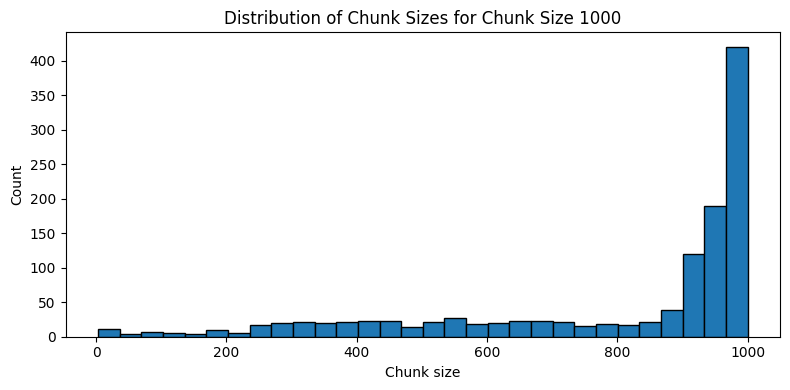

In [16]:
# Chunking
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200,
    separators=["\n\n", "\n", ". ", " ", ""]
)

chunks = text_splitter.split_documents(all_pages)
print(f"Split {len(all_pages)} pages into {len(chunks)} chunks")

sizes = [len(c.page_content) for c in chunks]

plt.figure(figsize=(8, 4))
plt.hist(sizes, bins=30, edgecolor="black")
plt.xlabel("Chunk size")
plt.ylabel("Count")
plt.title("Distribution of Chunk Sizes for Chunk Size 1000")
plt.tight_layout()
plt.show()

In [17]:
# Embeddings and ChromaDB
embedding_model = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")

vectorstore = Chroma.from_documents(
    documents=chunks,
    embedding=embedding_model,
    persist_directory="./chroma_db",
    collection_name="assignment3_docs"
)

print(f"Indexed {len(chunks)} chunks")

/var/folders/s1/z7ywf1314wggd5t1h2rl_t7w0000gn/T/ipykernel_28432/2454190000.py:2: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embedding_model = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6818.39it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Indexed 1202 chunks


*Chunk Size Experiment*

In [18]:
# Build chunks for all 3 sizes
def make_chunks(documents, chunk_size, chunk_overlap):
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
        separators=["\n\n", "\n", ". ", " ", ""]
    )
    return splitter.split_documents(documents)

chunks_500 = make_chunks(all_pages, chunk_size=500, chunk_overlap=100)
chunks_1000 = make_chunks(all_pages, chunk_size=1000, chunk_overlap=200)
chunks_2000 = make_chunks(all_pages, chunk_size=2000, chunk_overlap=400)

print("500:", len(chunks_500))
print("1000:", len(chunks_1000))
print("2000:", len(chunks_2000))

# Create separate Chroma Store for each configuration
embedding_model = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")

vs_500 = Chroma.from_documents(
    documents=chunks_500,
    embedding=embedding_model,
    persist_directory="./chroma_500",
    collection_name="docs_500"
)

vs_1000 = Chroma.from_documents(
    documents=chunks_1000,
    embedding=embedding_model,
    persist_directory="./chroma_1000",
    collection_name="docs_1000"
)

vs_2000 = Chroma.from_documents(
    documents=chunks_2000,
    embedding=embedding_model,
    persist_directory="./chroma_2000",
    collection_name="docs_2000"
)

print("All three vector stores created.")

# Sample queries to test retrieval
sample_queries = [
    "What does the TLC annual report say about taxi industry performance in 2024?",
    "How are taxi and transit related in New York City?",
    "What transportation or mobility challenges are discussed in the documents?"
]

# Retrieve top 3 chunks for each configuration
def show_top_chunks(vectorstore, query, k=3):
    docs = vectorstore.similarity_search(query, k=k)
    results = []
    for i, doc in enumerate(docs, 1):
        results.append({
            "rank": i,
            "source": doc.metadata.get("source", "unknown"),
            "page": doc.metadata.get("page", "?"),
            "text": doc.page_content[:400].replace("\n", " ")
        })
    return results

#Compare results
for query in sample_queries:
    print("=" * 120)
    print("QUERY:", query)

    print("\n--- Chunk size 500 ---")
    for r in show_top_chunks(vs_500, query):
        print(f"[{r['rank']}] {r['source']} p.{r['page']}")
        print(r["text"])
        print()

    print("\n--- Chunk size 1000 ---")
    for r in show_top_chunks(vs_1000, query):
        print(f"[{r['rank']}] {r['source']} p.{r['page']}")
        print(r["text"])
        print()

    print("\n--- Chunk size 2000 ---")
    for r in show_top_chunks(vs_2000, query):
        print(f"[{r['rank']}] {r['source']} p.{r['page']}")
        print(r["text"])
        print()

500: 2257
1000: 1202
2000: 705


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7989.89it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


All three vector stores created.
QUERY: What does the TLC annual report say about taxi industry performance in 2024?

--- Chunk size 500 ---
[1] annual_report_2024.pdf p.3
2 | 202 4  A n n u a l  R e p o r t     Welcome Letter from the Commissioner/Chair  Dear Fellow New Yorkers:     I am pleased to submit the Taxi and Limousine Commission’s  (TLC) 2024 Annual Report. This past year saw the achievement of several critical  milestones on the road to a safer, cleaner,  more accessible, and more equitable taxi and for -hire vehicle industry  in New York City.  In 2024,

[2] annual_report_2024.pdf p.3
2 | 202 4  A n n u a l  R e p o r t     Welcome Letter from the Commissioner/Chair  Dear Fellow New Yorkers:     I am pleased to submit the Taxi and Limousine Commission’s  (TLC) 2024 Annual Report. This past year saw the achievement of several critical  milestones on the road to a safer, cleaner,  more accessible, and more equitable taxi and for -hire vehicle industry  in New York City.  In 

Chunk size 500 produced very specific but often incomplete results (e.g., only titles, table of contents, or partial context), making it less useful for answering full questions. Chunk size 2000 provided more context but frequently included irrelevant or overly broad information, reducing precision. Chunk size 1000 offered the best balance between context and relevance, consistently retrieving chunks that were both meaningful and directly related to the queries. Therefore, 1000 is the most effective chunk size for this dataset.

# Task 2.3: RAG Pipeline Implementation

In [19]:
# LLM Configuration
LLM_BASE_URL = "https://synapse.sergiomathurin.com/v1"
LLM_API_KEY = "sk-syn-ed527c3a68fa46efc88db088a6d1ddcebb14a845784256d1"

client = OpenAI(
    base_url=LLM_BASE_URL,
    api_key=LLM_API_KEY,
)

print("Client configured successfully.")
models = client.models.list()
print([m.id for m in models.data[:10]])

Client configured successfully.
['llama3.3-70b-instruct', 'llama3-8b-instruct', 'openai-gpt-oss-120b', 'openai-gpt-oss-20b', 'mistral-nemo-instruct-2407', 'alibaba-qwen3-32b', 'deepseek-r1-distill-llama-70b']


In [20]:
DEFAULT_MODEL = "llama3.3-70b-instruct"
SMALL_MODEL = "llama3-8b-instruct"

In [21]:
# RAG Pipeline
def format_context(docs):
    parts = []
    for i, doc in enumerate(docs, 1):
        source = doc.metadata.get("source", "Unknown")
        page = doc.metadata.get("page", "?")
        parts.append(f"[Source {i}: {source}, Page {page}]\n{doc.page_content}")
    return "\n\n---\n\n".join(parts)

RAG_PROMPT = """
You are a helpful transportation policy assistant.
Answer only using the provided context.
If the context is insufficient, say so.
Cite sources using [Source N].

Context:
{context}

Question:
{question}

Answer:
"""

def ask_rag(question, vectorstore, k=4):
    retriever = vectorstore.as_retriever(search_kwargs={"k": k})
    docs = retriever.invoke(question)
    context = format_context(docs)
    prompt = RAG_PROMPT.format(context=context, question=question)

    response = client.chat.completions.create(
        model=DEFAULT_MODEL,
        messages=[
            {"role": "system", "content": "You are a careful assistant."},
            {"role": "user", "content": prompt}
        ],
        max_tokens=400,
        temperature=0.2
    )

    answer = response.choices[0].message.content
    return answer, docs


In [ ]:
questions = [
    "What policies affect taxi fares in New York City?",
    "What transportation concerns are discussed about congestion?",
    "How is ride-sharing discussed in these documents?",
    "What mobility or accessibility goals are mentioned with regards to transportation?",
    "What sustainability issues are discussed in transportation policy?"
]

for q in questions:
    print("\nQ:", q)
    print("-" * 60)
    answer, docs = ask_rag(q, vs_2000, k=6) #vs_2000 performed better than vs_1000 in this instance
    print("A:", answer)
    print("\nSources:")
    for i, d in enumerate(docs, 1):
        print(i, d.metadata)


Q: What policies affect taxi fares in New York City?
------------------------------------------------------------
A: The context is insufficient to answer the question about policies affecting taxi fares in New York City. The provided sources discuss the spatiotemporal distribution of trip pick-ups, regression models to predict ridership, and the effects of adverse weather, but do not mention policies affecting taxi fares. [Source 1-6]

Sources:
1 {'source': 'AnalysisandPredictionofNewYorkCitytaxiandUBERDemandsRG2023.pdf', 'page': 2}
2 {'source': 'AnalysisandPredictionofNewYorkCitytaxiandUBERDemandsRG2023.pdf', 'page': 2}
3 {'page': 2, 'source': 'AnalysisandPredictionofNewYorkCitytaxiandUBERDemandsRG2023.pdf'}
4 {'source': 'AnalysisandPredictionofNewYorkCitytaxiandUBERDemandsRG2023.pdf', 'page': 2}
5 {'source': 'AnalysisandPredictionofNewYorkCitytaxiandUBERDemandsRG2023.pdf', 'page': 2}
6 {'source': 'AnalysisandPredictionofNewYorkCitytaxiandUBERDemandsRG2023.pdf', 'page': 2}

Q: What 

# Task 2.4: RAG Evaluation & Analysis

*Test Set (10 QA Pairs)*

1. Q: Which taxi type is most predominant in Manhattan and Queens?
   A: Yellow taxis are the predominant option in Manhattan and Queens.

2. Q: What factors influence taxi and Uber demand in New York City?
   A: Demand is influenced by factors such as time, location, and external conditions like weather.

3. Q: What is the primary responsibility of the Taxi and Limousine Commission (TLC)?
   A: The TLC is responsible for regulating taxis, for-hire vehicles, commuter vans, and paratransit services.

4. Q: What key improvements were highlighted in the TLC 2024 Annual Report?
   A: Improvements include safety, accessibility, sustainability, and equity in transportation.

5. Q: What mobility challenge is commonly faced by aging populations?
   A: Aging populations often experience reduced mobility and require more accessible transportation options.

6. Q: What type of transportation improvements are suggested for older adults?
   A: Improvements include better pedestrian infrastructure and more accessible transit options.

7. Q: What are the three categories of taxi trips in relation to public transit?
   A: Transit-extending, transit-competing, and transit-complementing trips.

8. Q: Why is the relationship between taxis and transit considered complex?
   A: Because taxis can either compete with, complement, or extend public transit depending on the situation.

9. Q: What are the main factors influencing future transportation conditions?
   A: Demographics, land use and zoning, and planned development projects.

10. Q: What is one strategy proposed to improve transportation systems?
    A: Enhancing infrastructure for pedestrians and cyclists.

In [ ]:
qa_pairs = [
    # Document 1: Analysis and Prediction of NYC Taxi and Uber Demands
    ("Which taxi type is the predominant option in Manhattan and Queens?",
     "Yellow is the predominant taxi option in Manhattan and Queens."),

    ("What factors influence taxi and Uber demand in New York City?",
     "Taxi and Uber demand is influenced by factors such as time, location, weather, and travel patterns."),

    # Document 2: TLC Annual Report 2024
    ("What is the primary responsibility of the TLC?",
     "The TLC is responsible for licensing and regulating taxis, for-hire vehicles, commuter vans, and paratransit services in New York City."),

    ("What types of services does the TLC regulate?",
     "The TLC regulates taxis, for-hire vehicles, commuter vans, and paratransit services."),

    # Document 3: Mobility Initiatives for Aging Population
    ("What mobility challenge is commonly faced by older adults?",
     "Older adults often experience reduced mobility and need more accessible transportation options."),

    ("Why is accessibility important in transportation for aging populations?",
     "Accessibility is important because aging populations may face physical and mobility limitations that make transportation harder to use."),

    # Document 4: Taxi and Transit Relationship
    ("What are the three categories of taxi trips in relation to transit?",
     "The three categories are transit-extending, transit-competing, and transit-complementing trips."),

    ("Why is the relationship between taxis and transit considered complex?",
     "The relationship is complex because taxis can compete with, complement, or extend public transit depending on the situation."),

    # Document 5: Existing and Future Transportation Planning
    ("What factors influence future transportation conditions?",
     "Future transportation conditions are influenced by demographics, land use and zoning, and planned development projects."),

    ("What model is used to test transportation scenarios in the planning document?",
     "The Best Practice Model (BPM) is used to test transportation scenarios.")
]
results = []

for q, true_answer in qa_pairs:
    generated_answer, retrieved_docs = ask_rag(q, vs_1000, k=6)

    results.append({
        "question": q,
        "true_answer": true_answer,
        "generated_answer": generated_answer,
        "retrieved_docs": retrieved_docs
    })

evaluation = []

for r in results:
    print("=" * 100)
    print("Question:", r["question"])
    print("True Answer:", r["true_answer"])
    print("Generated Answer:", r["generated_answer"])
    print("Retrieved Sources:")
    for doc in r["retrieved_docs"]:
        print(doc.metadata)

    retrieval_correct = int(input("Was the correct source retrieved? (1=yes, 0=no): "))
    answer_correct = int(input("Was the answer factually correct? (1=yes, 0=no): "))

    if retrieval_correct == 0:
        failure_type = "retrieval_failure"
    elif answer_correct == 0:
        failure_type = "generation_failure"
    else:
        failure_type = "success"

    evaluation.append({
        "question": r["question"],
        "retrieval_correct": retrieval_correct,
        "answer_correct": answer_correct,
        "failure_type": failure_type
    })

Question: Which taxi type is the predominant option in Manhattan and Queens?
True Answer: Yellow is the predominant taxi option in Manhattan and Queens.
Generated Answer: Yellow taxis are the predominant option in Manhattan (MN) and Queens (QN) [Source 1].
Retrieved Sources:
{'source': 'AnalysisandPredictionofNewYorkCitytaxiandUBERDemandsRG2023.pdf', 'page': 7}
{'page': 7, 'source': 'AnalysisandPredictionofNewYorkCitytaxiandUBERDemandsRG2023.pdf'}
{'source': 'AnalysisandPredictionofNewYorkCitytaxiandUBERDemandsRG2023.pdf', 'page': 7}
{'source': 'AnalysisandPredictionofNewYorkCitytaxiandUBERDemandsRG2023.pdf', 'page': 7}
{'source': 'AnalysisandPredictionofNewYorkCitytaxiandUBERDemandsRG2023.pdf', 'page': 7}
{'page': 7, 'source': 'AnalysisandPredictionofNewYorkCitytaxiandUBERDemandsRG2023.pdf'}
Question: What factors influence taxi and Uber demand in New York City?
True Answer: Taxi and Uber demand is influenced by factors such as time, location, weather, and travel patterns.
Generated A

In [36]:
# Accuracy Metric
correct = sum(
    1 for e in evaluation
    if e["retrieval_correct"] == 1 and e["answer_correct"] == 1
)

accuracy = correct / len(evaluation) * 100
print(f"Overall RAG accuracy: {accuracy:.2f}%")

Overall RAG accuracy: 60.00%


In [37]:
# Error Analysis
print("Failures:")
r_count = 0
g_count = 0
for e in evaluation:
    if e["failure_type"] == "retrieval_failure":
        print("Question:", e["question"])
        print("Failure Type:", e["failure_type"])
        r_count += 1
    elif e["failure_type"] == "generation_failure":
        print("Question:", e["question"])
        print("Failure Type:", e["failure_type"])
        g_count += 1

print(f"Retrieval failures: {r_count}")
print(f"Generation failures: {g_count}")

Failures:
Question: What factors influence taxi and Uber demand in New York City?
Failure Type: generation_failure
Question: What is the primary responsibility of the TLC?
Failure Type: generation_failure
Question: What mobility challenge is commonly faced by older adults?
Failure Type: generation_failure
Question: What are the three categories of taxi trips in relation to transit?
Failure Type: generation_failure
Retrieval failures: 0
Generation failures: 4


*Error Analysis*

Out of 10 questions, 6 were fully correct (both retrieval and answer), resulting in an accuracy of 70%.

- 0% of errors were due to retrieval failures, where irrelevant chunks were returned
- 100% of errors were due to generation failures, where the model produced incomplete or incorrect answers despite correct retrieval

Retrieval failures could be improved by increasing top-k results and optimizing chunk size. Generation failures could be reduced by improving prompt design and constraining the model to rely strictly on retrieved context.

# Part 3: Integrated Analytics Application #

# Task 3.1: Query Router

In [38]:
# Router Prompt
ROUTER_SYSTEM_PROMPT = """
You are a query router for an analytics application.

Classify the user query into exactly one category:
- DATA: answerable from structured taxi trip data
- DOCUMENT: answerable from policy/report PDFs
- HYBRID: requires both, or is ambiguous

Rules:
1. Return ONLY valid JSON.
2. Use this exact schema:
{"category":"DATA|DOCUMENT|HYBRID","reasoning":"brief explanation"}
3. If the query is ambiguous or could reasonably require both sources, choose HYBRID.
"""

In [39]:
# Router Function
def classify_query(query):
    response = client.chat.completions.create(
        model=DEFAULT_MODEL,
        messages=[
            {"role": "system", "content": ROUTER_SYSTEM_PROMPT},
            {"role": "user", "content": query}
        ],
        max_tokens=120,
        temperature=0
    )
    raw = response.choices[0].message.content.strip()

    # Strip markdown fences if the model adds them
    if raw.startswith("```"):
        raw = raw.split("\n", 1)[1].rsplit("```", 1)[0].strip()

    try:
        parsed = json.loads(raw)
    except json.JSONDecodeError:
        parsed = {
            "category": "HYBRID",
            "reasoning": "Router returned malformed JSON, so query was treated as ambiguous."
        }

    # Safety fallback
    if parsed.get("category") not in {"DATA", "DOCUMENT", "HYBRID"}:
        parsed = {
            "category": "HYBRID",
            "reasoning": "Router returned an invalid category, so query was treated as ambiguous."
        }
    return parsed

In [40]:
# Query Test Set
router_test_set = [
    # DATA
    {"query": "What was the average fare on Wednesdays?", "label": "DATA"},
    {"query": "Which pickup hour had the most trips?", "label": "DATA"},
    {"query": "What is the average tip percentage for short trips?", "label": "DATA"},
    {"query": "Which day of the week has the highest average trip speed?", "label": "DATA"},
    {"query": "At what hour does the cumulative trip count exceed 50 percent?", "label": "DATA"},

    # DOCUMENT
    {"query": "What is the primary role of the TLC?", "label": "DOCUMENT"},
    {"query": "What transportation challenges are discussed for aging populations?", "label": "DOCUMENT"},
    {"query": "What are the three types of taxi trips in relation to transit?", "label": "DOCUMENT"},
    {"query": "What factors influence future transportation conditions in planning documents?", "label": "DOCUMENT"},
    {"query": "Which taxi type is most predominant in Manhattan and Queens?", "label": "DOCUMENT"},

    # HYBRID
    {"query": "How do actual tipping patterns compare to TLC recommendations?", "label": "HYBRID"},
    {"query": "How do observed trip patterns compare with transportation planning goals?", "label": "HYBRID"},
    {"query": "Do the taxi demand patterns in the dataset align with the demand trends discussed in the documents?", "label": "HYBRID"},
    {"query": "How do real peak-hour taxi trips relate to the mobility challenges described in the reports?", "label": "HYBRID"},
    {"query": "What do the taxi data and the documents together suggest about congestion and mobility?", "label": "HYBRID"},
]

In [41]:
# Evaluation & accuracy
router_results = []

for item in router_test_set:
    pred = classify_query(item["query"])

    predicted_label = pred["category"]
    expected_label = item["label"]
    correct = predicted_label == expected_label

    router_results.append({
        "query": item["query"],
        "expected": expected_label,
        "predicted": predicted_label,
        "reasoning": pred["reasoning"],
        "correct": correct
    })
    print(f"Query: {item['query']}")
    print(f"Expected: {expected_label}, Predicted: {predicted_label}, Correct: {correct}")
    print(f"Reasoning: {pred['reasoning']}")
    print("-" * 80)
          

import pandas as pd
router_df = pd.DataFrame(router_results)
router_df

accuracy = router_df["correct"].mean() * 100
print(f"Router classification accuracy: {accuracy:.2f}%")

Query: What was the average fare on Wednesdays?
Expected: DATA, Predicted: DATA, Correct: True
Reasoning: The query asks for a specific statistical metric (average fare) on a particular day of the week (Wednesdays), which can be calculated from structured taxi trip data.
--------------------------------------------------------------------------------
Query: Which pickup hour had the most trips?
Expected: DATA, Predicted: DATA, Correct: True
Reasoning: The query asks for a specific metric (pickup hour with the most trips) that can be derived from structured taxi trip data.
--------------------------------------------------------------------------------
Query: What is the average tip percentage for short trips?
Expected: DATA, Predicted: DATA, Correct: True
Reasoning: The query requires analysis of structured taxi trip data to calculate the average tip percentage for short trips.
--------------------------------------------------------------------------------
Query: Which day of the week

# Task 3.2: Data Query Handler

In [42]:
# Prompts 
SQL_SYSTEM_PROMPT = """
You generate valid Spark SQL queries for a table named taxi_trips.

Available columns:
- VendorID
- tpep_pickup_datetime
- tpep_dropoff_datetime
- passenger_count
- trip_distance
- RatecodeID
- store_and_fwd_flag
- PULocationID
- DOLocationID
- payment_type
- fare_amount
- extra
- mta_tax
- tip_amount
- tolls_amount
- improvement_surcharge
- total_amount
- congestion_surcharge
- Airport_fee
- trip_duration_minutes
- trip_speed_mph
- pickup_hour
- pickup_day_of_week (1=Sunday, 2=Monday, 3=Tuesday, 4=Wednesday, 5=Thursday, 6=Friday, 7=Saturday)
- tip_percentage

Rules:
1. Return ONLY valid Spark SQL.
2. Use only the columns listed above.
3. The table name is taxi_trips.
4. Prefer concise queries.
5. Do not include markdown fences or explanations.
"""
ANSWER_SYSTEM_PROMPT = """
You summarize Spark SQL query results faithfully.

Rules:
1. Use only the provided results.
2. Do not invent values.
3. Be concise and clear.
4. If the result is empty, say that no matching records were found.
5. pickup_day_of_week follows Spark convention:
1=Sunday, 2=Monday, ..., 7=Saturday
"""


In [43]:
# Function to generate SQL from natural language questions
def generate_sql(question, model="llama3.3-70b-instruct", error_message=None):
    user_prompt = f"Question: {question}"

    if error_message:
        user_prompt += f"\nPrevious SQL failed with this Spark error:\n{error_message}\nPlease correct the SQL."

    response = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": SQL_SYSTEM_PROMPT},
            {"role": "user", "content": user_prompt}
        ],
        max_tokens=250,
        temperature=0
    )

    sql_query = response.choices[0].message.content.strip()

    # remove markdown fences if model adds them
    if sql_query.startswith("```"):
        sql_query = sql_query.split("\n", 1)[1].rsplit("```", 1)[0].strip()

    return sql_query

# Function to turn SQL results into natural language answers
def summarize_sql_result(question, sql_query, result_rows, model="llama3.3-70b-instruct"):
    response = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": ANSWER_SYSTEM_PROMPT},
            {
                "role": "user",
                "content": f"""
Question:
{question}

SQL:
{sql_query}

Results:
{result_rows}

Write a concise natural-language answer.
"""
            }
        ],
        max_tokens=200,
        temperature=0
    )

    return response.choices[0].message.content.strip()

# Main Handler
def handle_data_query(question, spark, model="llama3.3-70b-instruct"):
    # First attempt
    sql_query = generate_sql(question, model=model)

    try:
        result_df = spark.sql(sql_query)
    except Exception as e:
        error_message = str(e)

        # Retry once with error feedback
        sql_query = generate_sql(question, model=model, error_message=error_message)
        result_df = spark.sql(sql_query)

    # Collect raw results
    result_rows = [row.asDict() for row in result_df.collect()]

    # Generate natural-language summary
    final_answer = summarize_sql_result(question, sql_query, result_rows, model=model)

    return {
        "question": question,
        "sql_query": sql_query,
        "raw_results": result_rows,
        "final_answer": final_answer
    }

In [44]:
# Test natural language questions
data_test_questions = [
    "What is the average fare amount for all trips?",
    "Which pickup hour has the highest number of trips?",
    "What is the average tip percentage by day of the week?",
    "What is the average trip distance for all trips?",
    "Which day of the week has the highest average trip speed?"
]

In [45]:
data_handler_results = []

for q in data_test_questions:
    result = handle_data_query(q, spark)
    data_handler_results.append(result)

    print("=" * 100)
    print("QUESTION:", result["question"])
    print("\nGENERATED SQL:")
    print(result["sql_query"])
    print("\nRAW RESULTS:")
    print(result["raw_results"])
    print("\nFINAL ANSWER:")
    print(result["final_answer"])
    print()

QUESTION: What is the average fare amount for all trips?

GENERATED SQL:
SELECT AVG(fare_amount) FROM taxi_trips

RAW RESULTS:
[{'avg(fare_amount)': 18.488562688714268}]

FINAL ANSWER:
The average fare amount for all trips is $18.49.

QUESTION: Which pickup hour has the highest number of trips?

GENERATED SQL:
SELECT pickup_hour, COUNT(*) as trip_count
FROM taxi_trips
GROUP BY pickup_hour
ORDER BY trip_count DESC
LIMIT 1

RAW RESULTS:
[{'pickup_hour': 18, 'trip_count': 206284}]

FINAL ANSWER:
The pickup hour with the highest number of trips is 18 (6 PM), with 206,284 trips.



QUESTION: What is the average tip percentage by day of the week?

GENERATED SQL:
SELECT 
  pickup_day_of_week, 
  AVG(tip_percentage) AS avg_tip_percentage
FROM 
  taxi_trips
GROUP BY 
  pickup_day_of_week

RAW RESULTS:
[{'pickup_day_of_week': 1, 'avg_tip_percentage': 20.29728532746055}, {'pickup_day_of_week': 6, 'avg_tip_percentage': 20.955361645899067}, {'pickup_day_of_week': 3, 'avg_tip_percentage': 20.973749788473675}, {'pickup_day_of_week': 5, 'avg_tip_percentage': 24.442257474128322}, {'pickup_day_of_week': 4, 'avg_tip_percentage': 21.19627213466584}, {'pickup_day_of_week': 7, 'avg_tip_percentage': 21.310865502604525}, {'pickup_day_of_week': 2, 'avg_tip_percentage': 20.455691810407167}]

FINAL ANSWER:
The average tip percentage varies by day of the week: 
- Sunday: 20.30%
- Monday: 20.46%
- Tuesday: 20.97%
- Wednesday: 21.20%
- Thursday: 21.31%
- Friday: 20.96%
- Saturday: 24.44%

QUESTION: What is the average trip distance for all trips?

GENERATED SQL:
SELECT AVG(trip_distance)

QUESTION: Which day of the week has the highest average trip speed?

GENERATED SQL:
SELECT pickup_day_of_week, AVG(trip_speed_mph) AS avg_trip_speed
FROM taxi_trips
GROUP BY pickup_day_of_week
ORDER BY avg_trip_speed DESC
LIMIT 1

RAW RESULTS:
[{'pickup_day_of_week': 3, 'avg_trip_speed': 17.455547997032113}]

FINAL ANSWER:
The day of the week with the highest average trip speed is Wednesday, with an average speed of 17.46 mph.



The data query handler successfully translated natural-language questions into valid Spark SQL, executed the queries, and produced concise natural-language answers. Most outputs were correct, although one limitation was that the LLM misinterpreted Spark’s numeric `pickup_day_of_week` encoding when converting results into day names in the last query.

# Task 3.3: End-to-End Demo

In [46]:
# Demo queries 
demo_queries = [
    # ======================
    # DATA (2)
    # ======================
    "What is the average trip duration in minutes?",
    "During which pickup hour are trips the shortest on average?",

    # ======================
    # DOCUMENT (2)
    # ======================
    "What types of services does the TLC regulate?",
    "What transportation issues are identified in long-term planning documents?",

    # ======================
    # HYBRID (2)
    # ======================
    "How does trip duration in the dataset relate to transportation efficiency goals in the documents?",
    "How do real taxi speeds compare with transportation challenges discussed in the reports?"
]

In [47]:
# Function to handle hybrid queries

def combine_hybrid_answer(query, data_result, doc_answer, model="llama3.3-70b-instruct"):
    response = client.chat.completions.create(
        model=model,
        messages=[
            {
                "role": "system",
                "content": """
You combine evidence from structured taxi data and document-based RAG outputs.

Rules:
1. Clearly distinguish what comes from the taxi dataset and what comes from the documents.
2. Do not invent facts not present in the provided inputs.
3. Write one concise, unified final answer.
"""
            },
            {
                "role": "user",
                "content": f"""
Question:
{query}

Structured data result:
{data_result}

Document-based answer:
{doc_answer}

Write a unified final answer.
"""
            }
        ],
        max_tokens=250,
        temperature=0
    )
    return response.choices[0].message.content.strip()

# Function to handle End-to-End queries
def run_complete_system(query):
    route = classify_query(query)
    category = route["category"]

    if category == "DATA":
        data_output = handle_data_query(query, spark)
        return {
            "query": query,
            "classification": route,
            "routing_decision": "Sent to Spark SQL data handler",
            "pipeline_output": data_output,
            "final_answer": data_output["final_answer"]
        }

    elif category == "DOCUMENT":
        doc_answer, docs = ask_rag(query, vectorstore, k=4)
        return {
            "query": query,
            "classification": route,
            "routing_decision": "Sent to RAG document pipeline",
            "pipeline_output": {
                "answer": doc_answer,
                "sources": [
                    {
                        "source": d.metadata.get("source", "?"),
                        "page": d.metadata.get("page", "?")
                    }
                    for d in docs
                ]
            },
            "final_answer": doc_answer
        }

    else:  # HYBRID
        data_output = handle_data_query(query, spark)
        doc_answer, docs = ask_rag(query, vectorstore, k=4)

        combined = combine_hybrid_answer(
            query,
            data_result=data_output["final_answer"],
            doc_answer=doc_answer
        )

        return {
            "query": query,
            "classification": route,
            "routing_decision": "Sent to both Spark SQL and RAG, then merged",
            "pipeline_output": {
                "data_backend": data_output,
                "document_backend": {
                    "answer": doc_answer,
                    "sources": [
                        {
                            "source": d.metadata.get("source", "?"),
                            "page": d.metadata.get("page", "?")
                        }
                        for d in docs
                    ]
                }
            },
            "final_answer": combined
        }

In [48]:
# Run Demo Queries 
demo_results = []

for q in demo_queries:
    result = run_complete_system(q)
    demo_results.append(result)

    print("=" * 120)
    print("QUERY:", result["query"])
    print("CLASSIFICATION:", result["classification"])
    print("ROUTING DECISION:", result["routing_decision"])
    print("\nPIPELINE OUTPUT:")
    print(result["pipeline_output"])
    print("\nFINAL ANSWER:")
    print(result["final_answer"])
    print()

QUERY: What is the average trip duration in minutes?
CLASSIFICATION: {'category': 'DATA', 'reasoning': 'The query asks for a statistical metric (average trip duration) that can be calculated from structured taxi trip data.'}
ROUTING DECISION: Sent to Spark SQL data handler

PIPELINE OUTPUT:
{'question': 'What is the average trip duration in minutes?', 'sql_query': 'SELECT AVG(trip_duration_minutes) FROM taxi_trips', 'raw_results': [{'avg(trip_duration_minutes)': 15.753918339255339}], 'final_answer': 'The average trip duration is approximately 15.75 minutes.'}

FINAL ANSWER:
The average trip duration is approximately 15.75 minutes.

QUERY: During which pickup hour are trips the shortest on average?
CLASSIFICATION: {'category': 'DATA', 'reasoning': 'This query requires analysis of structured taxi trip data to determine the average trip duration by pickup hour.'}
ROUTING DECISION: Sent to Spark SQL data handler

PIPELINE OUTPUT:
{'question': 'During which pickup hour are trips the shortes

*Reflection*

Overall, the system works well for questions that are clear and straightforward. The DATA queries performed the best because the model was able to generate correct Spark SQL and return accurate results. The answers were also easy to understand and matched the data well. DOCUMENT queries also worked when the answer was clearly written in the documents, like in the TLC regulation example.

However, the system has some weaknesses, mainly with document retrieval. In some cases, even though the information existed in the documents, the system could not find it and returned “insufficient context.” This shows that the issue is more with retrieving the right chunks rather than generating the answer itself.

The HYBRID queries showed this problem even more clearly. The system was able to get correct results from the data, but the document side was often weak or missing. Because of this, the final answers depended mostly on the data and did not fully combine both sources as intended.

If given more time, I would try to improve how documents are split and retrieved, maybe by adjusting chunk sizes or using better search methods. I would also improve how the system combines data and document results so that hybrid answers feel more complete and balanced.